In [1]:
import os
import pandas as pd
import pickle
import numpy as np
from IPython.display import Image

os.chdir(r'C:/Users/mikei/OneDrive/Desktop/Python/nba_breakout_analysis')

all_candidates = pd.read_csv('data/nba_breakout_candidates.csv')
with open('models/diff_model.pkl', 'rb') as f:
    diff_model = pickle.load(f)
with open('models/following_model.pkl', 'rb') as f:
    following_model = pickle.load(f)
with open('models/logit_model.pkl', 'rb') as f: 
    logit_model = pickle.load(f)        


# Is it just a Mirage: Can Breakout Players in the NBA Sustain their Surge in the Age of Tanking
**Author:** Mike Zhang
**Date:** 2026-03-31



## Introduction 

Since time immemorial, tanking has been an issue in the NBA. Over the past few years, with loads of generational talents like Victor Wembanyama and Cooper Flagg entering the league every year, the tanking measurements adopted by teams have become, well, more and more blatant, whether they are teams that were in the middle of a dog fight in the finals yet somehow predicted their best player was about to tear his achilles a few days later like the Pacers, accumulate assets for the future like the Nets, cross fingers for a miracle after trading away their franchise like the Mavs, or simply be the Sacramento Kings who started Kilian Hayes for the last game.

It's bad for the game, I get it. But at the same time, it allows teams to experiment with their lineups and develop players who otherwise might not get enough playing time to show what they can actually do on the court. Take the now all-star Deni Avdija as an example. After spending four underwhelming years in D.C., he was traded to the Blazers for cheap, and during his first season with the Blazers, he still merely looked like a high-caliber role player at best, averaging a serviceable 14/6/3 with mediocre efficiency, just slightly better than what he did with the Wizards. However, he suddenly emerged as a breakout candidate since the All-Star break, stuffing the statsheet with a stunning 23/9/5 line with an impressive 50%/40%/78% split. Avdija finished the 24-25 season strong, but rumors of him starting the 25-26 season off the bench were still circulating in the off-season, showing just how fans and analysts are treating stats from the so-called Mickey-mouse March with caution nowadays.

This raises a natural question: are post-All-Star breakouts on tanking teams real, or just noise?

## Data
All data for this project are obtained from the official `nba_api` endpoints. Breakout seasons span from 2014-15 to 2024-25, with following-season stats drawn through 2025-26. The 2019-20 season is excluded due to being disrupted by COVID-19. In order to capture the "big leap in a tanking team after the All-Star break" as accurately as possible, multiple inclusion criteria are implemented. 

To qualify, a player must: 
1. be no older than 28 (`AGE_post <= 28`)
2. be on a tanking team, defined as having a bottom-12 win rate (`W_PCT`) by the All-Star break 
3. be at least a rotation-level player before All-Star breaks, defined as averaging at least 10 minutes of playing time and playing at least 15 games (`MIN_pre >= 10 & GP_pre >= 15`) 
4. have demonstrated a breakout after All-Star breaks by either having a major PIE change of at least 0.02 (`PIE_change >= 0.02`) or a 30% jump in playing time per game (`MIN_post >= 1.3 * MIN_pre`)
5. not be an established star, defined as having a prior season PIE no greater than 0.11 (`PIE_prior <= 0.11`)
6. played at least 30 games the following season to ensure a sufficient sample for measuring following seasons' performance (`GP_following >= 30`)

 Ultimately, the inclusion criteria yield 120 players for my analysis.

 It's worth noticing that many of these criteria are rather arbitrary and based on my personal basketball knowledge as well as judgement. Although position isn't a significant variable in any of the regression models later on, it is also interesting to note that there are fewer centers (`n = 11`, 9.2%) than guards (`n = 72`, 60%) and fowards (`n = 37`, 30.8%) who qualify for our analysis. In addition, as shown in the boxplot below, centers generally show a tighter distribution of the changes in their pre- and post-All-Star break PIEs, compared with guards and fowards, suggesting that big men's development is slower and steadier, which alignes with common basketball knowledge.  

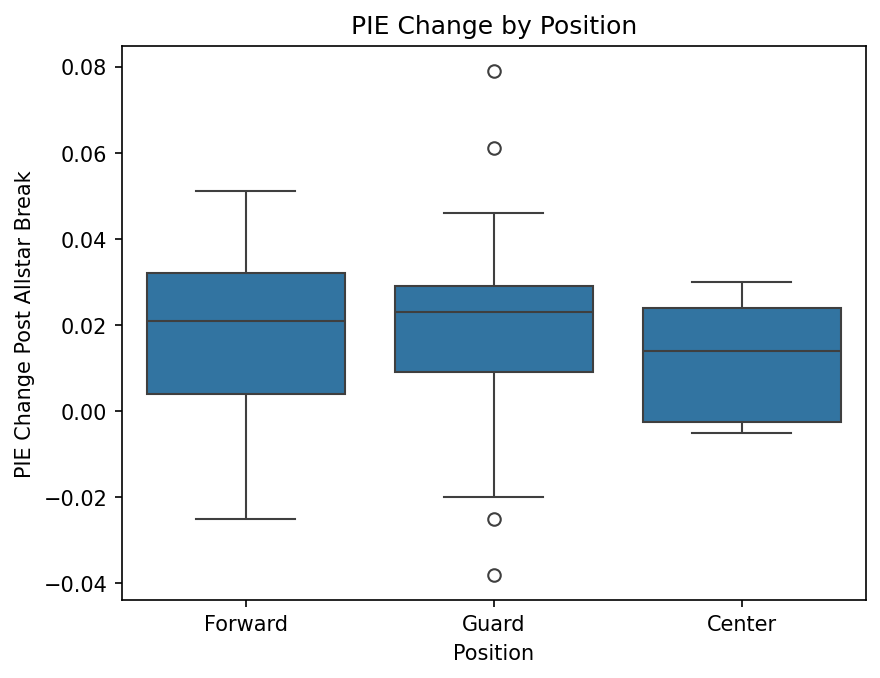

In [9]:
Image('plots/position_boxplot.png')

## Methods

To capture players' performance, I utilized Player Impact Estimate (PIE), a box score-based advanced metric that measures a player's overall percentage contribution to game outcomes. While PIE has known limitations, namely its sensitivity to playing time and its reliance solely on box score events, it was selected for its direct accessibility through `nba_api`. More robust metrics such as estimated plus-minus would be preferable but require either paid third-party subscriptions or manual data collection from sources like basketballreference and dunksandthrees. PIE is therefore used as a practical proxy, and its limitations are acknowledged in the Discussion section.

Multiple linear regression and logistic regression are utilized, with players' age after all-star breaks (`AGE_post`), pre- and post-All-Star break PIE change (`PIE_change`), and players' positions (`POSITION_simplified`) as predictors. Age is an important indicator of whether a player would breakout or whether their breakout would sustain. We see young players leap into stardoms and proceede to dominate the league onwards on a regular basis, but we rarely see that happen on veterans who are already molded into certain archetypes of players. In theory, players' positions would matter too because guards and wings tend to have a larger bump in usage and roles than bigs, especially for tanking teams where they ironically want those less efficient smalls to brick as many shots as possible to help them lose games. In addition, `PIE_change` captures the magnitude of the breakout itself and is expected to predict both regression magnitude and absolute following-season performance through mean reversion.

Linear regression is run on both the primary outcome, the difference between post-All-Star break PIE and the following season's PIE (`PIE_diff`), and the secondary outcome, absolute PIE in the following season (`PIE_following`). More predictors were included in the model originally, but severe multicollinearity was present among certain variables whose VIFs exceeded 5. These variables were eventually dropped. For the logistic regression, `PIE_diff` is transformed into a binary outcome, `sustained`, to indicate whether a player sustains their post-All-Star surge or not. Odds ratios are reported in place of raw coefficients for interpretability, as they express the multiplicative change in odds of sustaining a breakout for a given unit change in each predictor. Influential observations are identified using Cook's Distance with a threshold of 4/n. Identified players are annotated on the scatter plot in the results section.

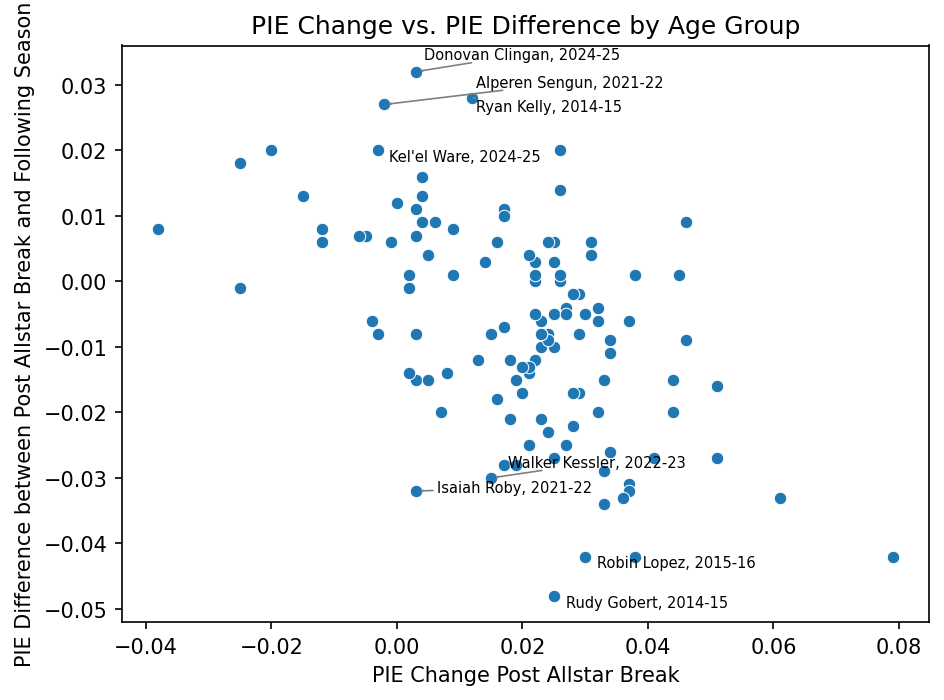

In [3]:
Image('plots/outlier_scatter.png')

## Results

Three models were estimated to examine the relationship between post-All-Star breakout characteristics and following-season performance.

The primary linear regression model uses `POSITION_simplified`, `AGE_post`, and `PIE_change` as predictors and `PIE_diff` as the outcome. The model summary is displayed in the table below.

In [5]:
display(diff_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PIE_diff   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     15.28
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.75e-10
Time:                        15:55:48   Log-Likelihood:                 352.08
No. Observations:                 120   AIC:                            -694.2
Df Residuals:                     115   BIC:                            -680.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0450      0.013      3.460      0.001       0.019       0.071
C(POSITION_simplified)[T.Forward]     0.0037      0.005      0.800      0.425      -0.005       0.013
C(POSITION_simplified)[T.Guard]       0.0030      0.004      0.698      0.486      -0.006       0.012
PIE_change                           -0.4739      0.068     -6.934      0.000      -0.609      -0.339
AGE_post                             -0.0020      0.001     -3.587      0.000      -0.003      -0.001
==============================================================================
Omnibus:                        0.153   Durbin-Watson:                   1.933
Prob(Omnibus):                  0.926   Jarque-Bera (JB):                0.127
Skew:                          -0.075   Prob(JB):                        0.939
Kurtosis:                       2.946   Cond. No.                     1.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.31e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The primary OLS model explains approximately 33% of variance in PIE_diff (R² = 0.324, F = 15.28, p < 0.001). As shown above, both `AGE_post`(p < 0.001) and `PIE_change` (p < 0.001) are negatively associated with `PIE_diff`, indicating that younger players and those with relatively modest breakout are likely to sustain their performance the next season. More specifically, players who are one year younger have 0.002 less PIE dropoff in their following seasons' PIE, and for every 0.01 increase in post-All-Star PIE change, PIE_diff decreases by approximately 0.005.

In [2]:
display(following_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          PIE_following   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     9.512
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.11e-06
Time:                        16:09:37   Log-Likelihood:                 298.24
No. Observations:                 120   AIC:                            -586.5
Df Residuals:                     115   BIC:                            -572.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.1163      0.020      5.713      0.000       0.076       0.157
C(POSITION_simplified)[T.Forward]    -0.0265      0.007     -3.684      0.000      -0.041      -0.012
C(POSITION_simplified)[T.Guard]      -0.0284      0.007     -4.198      0.000      -0.042      -0.015
PIE_change                            0.5361      0.107      5.008      0.000       0.324       0.748
AGE_post                             -0.0003      0.001     -0.400      0.690      -0.002       0.001
==============================================================================
Omnibus:                        0.952   Durbin-Watson:                   1.836
Prob(Omnibus):                  0.621   Jarque-Bera (JB):                0.602
Skew:                           0.154   Prob(JB):                        0.740
Kurtosis:                       3.159   Cond. No.                     1.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.31e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The seconary OLS model uses players' PIE in the following season as the outcome and explains only approximately 22% of variance in PIE_diff (R² = 0.222, F = 9.512, p < 0.001). As shown in the model output and unlike the primary model, only `PIE_change` (p < 0.001) are positively associated with `PIE_following`, indicating that a bigger breakout post-all-star-break in the previous season does predict a higher absolute PIE value in the following season, even if the magnitude of improvments might not be sustainable. Though age is a significant predictor of `PIE_diff`, it is not associated with `PIE_following`, meaning while age influences the magnitude of regression, it does not meaningfully predict where a player ultimately lands in absolute performance terms.

In [ ]:
display(logit_model.summary())
odds_ratios = np.exp(logit_model.params)
conf = np.exp(logit_model.conf_int().rename(columns={0: '2.5%', 1: '97.5%'}))
conf['OR'] = odds_ratios
print(conf)

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              sustained   No. Observations:                  120
Model:                          Logit   Df Residuals:                      115
Method:                           MLE   Df Model:                            4
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.1434
Time:                        16:24:43   Log-Likelihood:                -68.820
converged:                       True   LL-Null:                       -80.339
Covariance Type:            nonrobust   LLR p-value:                 0.0001245
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             2.8866      2.292      1.259      0.208      -1.607       7.380
C(POSITION_simplified)[T.Forward]     0.3645      0.775      0.470      0.638      -1.154       1.883
C(POSITION_simplified)[T.Guard]       0.2419      0.728      0.332      0.740      -1.185       1.668
PIE_change_scaled                    -0.5807      0.144     -4.029      0.000      -0.863      -0.298
AGE_post                             -0.1120      0.100     -1.122      0.262      -0.307       0.084
=====================================================================================================
"""

                                       2.5%        97.5%         OR
Intercept                          0.200587  1602.995866  17.931529
C(POSITION_simplified)[T.Forward]  0.315320     6.574274   1.439792
C(POSITION_simplified)[T.Guard]    0.305885     5.303036   1.273624
PIE_change_scaled                  0.421809     0.742112   0.559490
AGE_post                           0.735325     1.087120   0.894084


In [8]:
all_candidates['sustained'] = (all_candidates['PIE_diff'] >= 0).astype(int)
all_candidates['sustained'].value_counts()

sustained
0    73
1    47
Name: count, dtype: int64

The logistic regression model is statistically significant (LLR p < 0.001), though modest in explanatory power (pseudo R² = 0.1434). Of the 120 breakout candidates, 47 sustained their post-All-Star performance the following season (39.2%), while 73 regressed (60.8%). `PIE_change` was the only significant predictor (p < 0.001). For every 1 percentage point increase in post-All-Star PIE change, the odds of sustaining a breakout decreased by approximately 44% (OR = 0.56, 95% CI: 0.42, 0.74). This is consistent with the primary OLS finding that breakout magnitude predicts greater regression. `AGE_post` and position were not significant predictors of sustaining a breakout, suggesting that while age predicts regression magnitude in the primary OLS model, it does not determine whether a player sustains their performance at all.

## Discussions

Overall, the results show that, of the 120 breakout candidates on tanking teams, 60.8% failed to sustain their post-All-Star performance the following season. In addition, the bigger their leaps are, the harder they would fall the following season, consistent with statistical regression to the mean. However, several positive outliers do exist, such as Donovan Clingan and Kel'el Ware, who saw a bigger role at the end of 24-25 season and then proceeded to become fleshed out starters during 25-26 season. 

Regression to the mean is a statistical phenomenon where, if a variable is extreme on its first measurement, it will tend to be closer to the average (the mean) on its second measurement. It's particularly applicable in this context because, with the limited amount of games players played after all-star-breaks, their stats could be inflated and deceiving, especially if the teams were actively tanking by handing the keys to objectively bad players who happened to get more usage, but only temporarily. 

This explains why players who saw larger jumps in their PIE after all-star breaks tend to regress more the following season: they simply fall off for various reasons - hard to pad stats when every team was trying to compete during the first half of the following seasons, teams that were tanking during the breakout season may have become more competitive the following year, reducing opportunities for fringe players, mediocre players lost usage and playing time to more promising and talented players, and so on. Consequently, full-season statistics from the following season usually correct for the extreme and noisy statistics in March and April due to the blatant league-wide tanking scheme.

In terms of the magnitude of the fall-off, younger players seem to better sustain their breakout than older players, although age is not significantly associated with absolute PIE in the following season. This finding is consistent with what's observed in practice where teams generally invest more and are more patient in younger players, especially those who are still developing their game. For young players still trending upwards, a considerable leap is also more likely an indicator of real growth rather than a fluke, and conversely, teams usually are willing to bet on breaking out young players by giving them more opportunities the next season. Older players, on the contrary, might've already settled into a specific archetype or held certain reputation - teams and coaches would be more skeptical of someone who hasn't been able to hit jumpers consistently for years suddenly starting to hit 40% of threes, and understandably so, as a sudden yet sustained growth among veterans is relatively rare.

Furthermore, visual inspection suggests age may play an even more nuanced role. The age-binned plot below suggests older players don't just regress more on average and that the slope of regression appears steeper for older age groups, hinting that age moderates the relationship between breakout magnitude and regression. The interaction term `PIE_change * AGE_post` was tested yet failed to reach significance (p = ) potentially due to low power with `n = 120`. It might be an interesting topic to explore in the future as more seasons data become available.

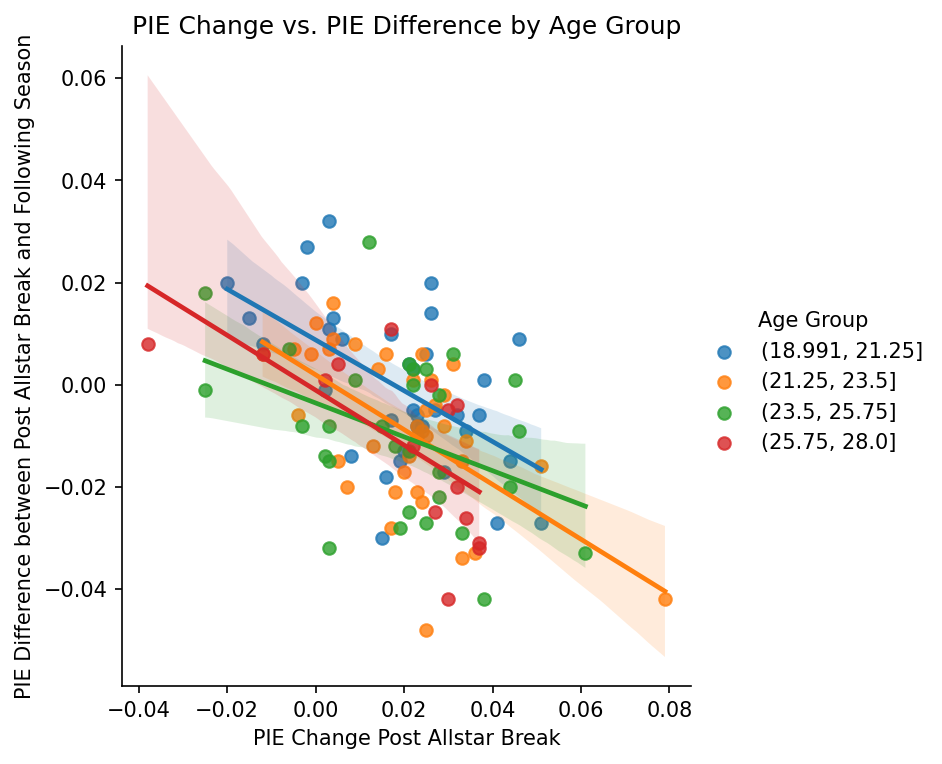

In [2]:
Image('plots/age_binned_regression.png')

Moreover, centers tend to land at higher absolute PIE the following season in the secondary OLS model possibly because bigs' boxscore contributions, which mostly comes from rebounding, are more stable and less usage-dependent than guards and wings who need the ball in their hands to either generate assists or score. This finding should be interpreted cautiously given that position did not reach significance in the primary or logistic models.

## Limitations

Several limitations are present throughout the project. First of all, as stated before, PIE is an inferior advanced metric calculated based on boxscores, which are highly dependent on playing time and might not accurately reflect a player's true performance. In addition, a sample size of 120 somewhat limits the statistical power, particularly for interaction terms and logistic regression events-per-variable. Injury is also not accounted for in the analyses. A player who regresses due to injury is a fundamentally different case than one who simply couldn't sustain performance. Unfortunately, detailed injury information is not available in `nba_api`. Next, both the criteria for tanking teams and breakout players are somewhat loosely defined based on domain knowledge and established conventions in basketball analytics, and results might vary if the definitions change. Team continuity, while theoretically motivated, did not reach significance, possibly reflecting insufficient power rather than a true null effect.